<a href="https://colab.research.google.com/github/zainabsherbazcs/three-body-gravity-simulation/blob/main/Three_Body_Gravity_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Let's define Newton's Gravitational Constant (normalized for simple modeling)
G = 1.0

# Set up the masses of three stars (Star 1 is massive, Stars 2 and 3 are smaller)
m1 = 2.0
m2 = 1.0
m3 = 1.0

print("Astrophysics workspace initialized! Masses locked in for the Three-Body gravitational system.")


Astrophysics workspace initialized! Masses locked in for the Three-Body gravitational system.


In [3]:
# The differential equations model for 3-body gravitational interactions
def three_body_equations(t, y, G, m1, m2, m3):
    # Split the massive coordinate vector into individual positions (r) and velocities (v)
    r1, v1 = y[0:3], y[3:6]
    r2, v2 = y[6:9], y[9:12]
    r3, v3 = y[12:15], y[15:18]

    # Calculate distances (displacement vectors) between each star pairs
    r12 = r2 - r1
    r13 = r3 - r1
    r23 = r3 - r2

    # Calculate regularized vector magnitudes (with epsilon buffers to avoid division by zero)
    eps = 1e-3
    mag12 = (np.dot(r12, r12) + eps)**1.5
    mag13 = (np.dot(r13, r13) + eps)**1.5
    mag23 = (np.dot(r23, r23) + eps)**1.5

    # Apply Newton's Inverse-Square Law to calculate vector accelerations (forces)
    a1 = G * m2 * r12 / mag12 + G * m3 * r13 / mag13
    a2 = -G * m1 * r12 / mag12 + G * m3 * r23 / mag23
    a3 = -G * m1 * r13 / mag13 - G * m2 * r23 / mag23

    # Package positions and velocities back into a continuous derivative array
    return [v1[0], v1[1], v1[2], a1[0], a1[1], a1[2],
            v2[0], v2[1], v2[2], a2[0], a2[1], a2[2],
            v3[0], v3[1], v3[2], a3[0], a3[1], a3[2]]

print("Gravitational force vector equations mapped! Ready to launch coordinates.")


Gravitational force vector equations mapped! Ready to launch coordinates.


In [4]:
# Setting up 3D starting coordinates [X, Y, Z] for each star
r1_init = [-1.0, 0.0, 0.0]  # Star 1 starts on the left
r2_init = [1.0, 0.0, 0.0]   # Star 2 starts on the right
r3_init = [0.0, 0.8, 0.0]   # Star 3 starts slightly higher up

# Setting up 3D starting velocity vectors [Vx, Vy, Vz]
v1_init = [0.1, 0.4, 0.0]
v2_init = [-0.1, -0.4, 0.0]
v3_init = [0.0, 0.0, 0.0]   # Star 3 starts at rest, waiting to be pulled

# Pack all starting states into a master vector array
initial_state = np.concatenate([r1_init, v1_init, r2_init, v2_init, r3_init, v3_init])

# Set simulation time span: 0 to 30 seconds across 2000 step updates
t_span = (0, 30)
t_eval = np.linspace(0, 30, 2000)

# Run the computer algorithm to simulate the physics over time
solution = solve_ivp(three_body_equations, t_span, initial_state, args=(G, m1, m2, m3), t_eval=t_eval)

print("Orbital tracking simulation processed successfully! Ready to render the trajectories.")


Orbital tracking simulation processed successfully! Ready to render the trajectories.


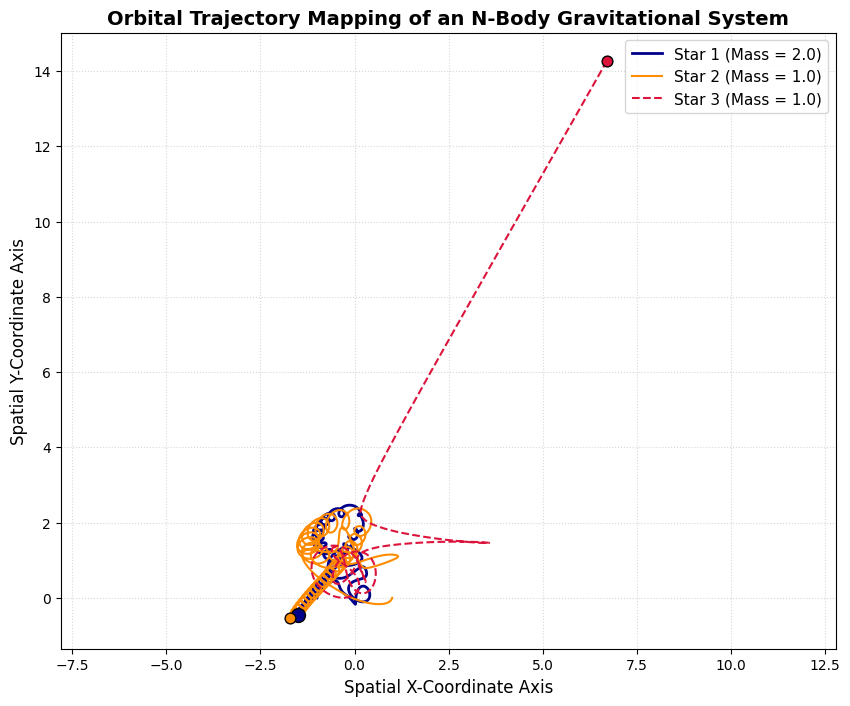

In [5]:
plt.figure(figsize=(10, 8))

# Extract the X and Y coordinate data arrays for each star from the solution
x1, y1 = solution.y[0], solution.y[1]
x2, y2 = solution.y[6], solution.y[7]
x3, y3 = solution.y[12], solution.y[13]

# Plot the continuous orbital tracking lines for each star over time
plt.plot(x1, y1, label='Star 1 (Mass = 2.0)', color='darkblue', linewidth=2)
plt.plot(x2, y2, label='Star 2 (Mass = 1.0)', color='darkorange', linewidth=1.5)
plt.plot(x3, y3, label='Star 3 (Mass = 1.0)', color='crimson', linewidth=1.5, linestyle='--')

# Draw distinct marker circles representing the final positions of the stars
plt.scatter(x1[-1], y1[-1], color='darkblue', s=100, edgecolors='black', zorder=5)
plt.scatter(x2[-1], y2[-1], color='darkorange', s=60, edgecolors='black', zorder=5)
plt.scatter(x3[-1], y3[-1], color='crimson', s=60, edgecolors='black', zorder=5)

# Add formal academic styling, labels, and legends
plt.title('Orbital Trajectory Mapping of an N-Body Gravitational System', fontsize=14, fontweight='bold')
plt.xlabel('Spatial X-Coordinate Axis', fontsize=12)
plt.ylabel('Spatial Y-Coordinate Axis', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')
plt.axis('equal') # Keeps the physical proportions accurate on screen

plt.show()
